## Setup

In [ ]:
pip install numpy matplotlib tensorflow

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory


## 1. Dataset Exploration (EDA)

### 1.1 Path to dataset

In [8]:
data_root = "DataSet/Train_images/Train_images"

classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])
class_to_files = {
    c: [os.path.join(data_root, c, f) for f in os.listdir(os.path.join(data_root, c))]
    for c in classes
}

### 1.2 Dataset size and class distribution

In [9]:
class_counts = {c: len(files) for c, files in class_to_files.items()}
num_images = sum(class_counts.values())

print("Classes:", classes)
print("Total images:", num_images)
print("Class distribution:")
for c, n in class_counts.items():
    print(f"  {c}: {n}")

Classes: ['Cigar-shaped smooth', 'In between smooth', 'completely round smooth', 'edge-on', 'spiral']
Total images: 28793
Class distribution:
  Cigar-shaped smooth: 579
  In between smooth: 8069
  completely round smooth: 8436
  edge-on: 3903
  spiral: 7806


### 1.3 Image dimensions and channels

In [10]:
print("\nSample image shapes per class:")
for c in classes:
    sample_path = class_to_files[c][0]
    img = mpimg.imread(sample_path)
    print(f"  {c}: {img.shape}")


Sample image shapes per class:
  Cigar-shaped smooth: (424, 424, 3)
  In between smooth: (424, 424, 3)
  completely round smooth: (424, 424, 3)
  edge-on: (424, 424, 3)
  spiral: (424, 424, 3)


### 1.4 Show example samples per class and hiding empty subplots

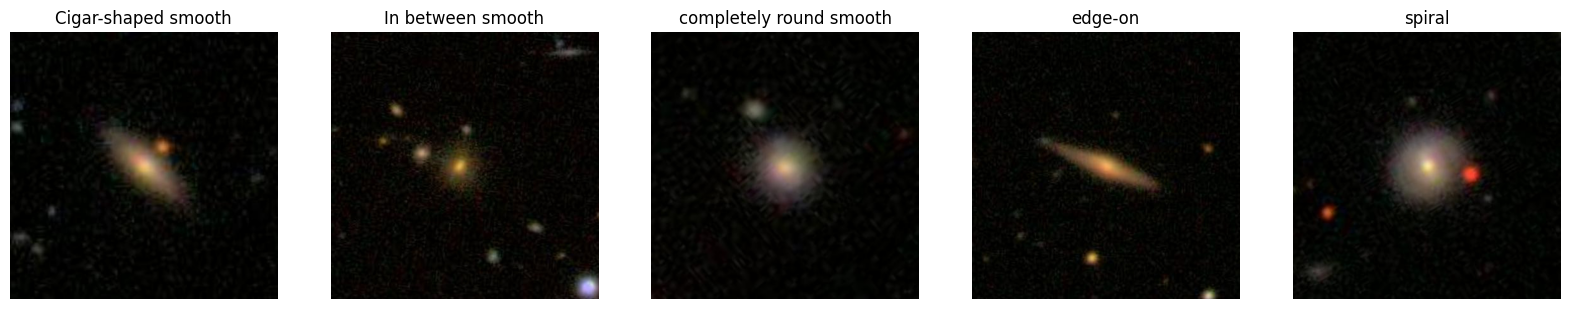

In [12]:
cols = min(5, len(classes))
rows = int(np.ceil(len(classes) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, c in zip(axes, classes):
    sample_path = class_to_files[c][0]
    img = mpimg.imread(sample_path)
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(c)
    ax.axis("off")

In [13]:
for ax in axes[len(classes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### 1.5 Preprocessing (Normalization)

In [14]:
sample_path = class_to_files[classes[0]][0]
img = mpimg.imread(sample_path)

if img.max() > 1:
    img_norm = img / 255.0
else:
    img_norm = img.astype("float32")

print("Original dtype/range:", img.dtype, (img.min(), img.max()))
print("Normalized dtype/range:", img_norm.dtype, (img_norm.min(), img_norm.max()))

Original dtype/range: uint8 (np.uint8(0), np.uint8(242))
Normalized dtype/range: float64 (np.float64(0.0), np.float64(0.9490196078431372))


### 1.6 EDA Summary

In [17]:
max_per_class = 50 
sample_shapes = []

for c in classes:
    for p in class_to_files[c][:max_per_class]:
        img = mpimg.imread(p)
        sample_shapes.append(img.shape)

unique_shapes = sorted(set(sample_shapes))
channels = sorted({s[2] if len(s) == 3 else 1 for s in unique_shapes})

print("EDA Summary")
print("- Total images:", num_images)
print("- Classes:", len(classes), classes)
print("- Class distribution:", class_counts)
print("- Unique image shapes (sampled):", unique_shapes[:5], "..." if len(unique_shapes) > 5 else "")
print("- Channels:", channels)
print("- Preprocessing: normalize to [0, 1]")

EDA Summary
- Total images: 28793
- Classes: 5 ['Cigar-shaped smooth', 'In between smooth', 'completely round smooth', 'edge-on', 'spiral']
- Class distribution: {'Cigar-shaped smooth': 579, 'In between smooth': 8069, 'completely round smooth': 8436, 'edge-on': 3903, 'spiral': 7806}
- Unique image shapes (sampled): [(424, 424, 3)] 
- Channels: [3]
- Preprocessing: normalize to [0, 1]


## 2. Baseline Model (Non-Convolutional)

### 2.1 Build train/validation datasets

In [18]:
sample_img = mpimg.imread(class_to_files[classes[0]][0])
if sample_img.ndim == 2:
    img_height, img_width = sample_img.shape
    num_channels = 1
else:
    img_height, img_width, num_channels = sample_img.shape

image_size = (img_height, img_width)
print("Using image_size:", image_size, "channels:", num_channels)

batch_size = 32
seed = 123

train_ds = image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
)

val_ds = image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Using image_size: (424, 424) channels: 3
Found 28793 files belonging to 5 classes.
Using 23035 files for training.


2026-02-03 20:03:05.412842: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 28793 files belonging to 5 classes.
Using 5758 files for validation.


### 2.2 Baseline architecture (Flatten + Dense)

In [19]:
num_classes = len(classes)

baseline_model = models.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=(img_height, img_width, num_channels)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()
print("Total parameters:", baseline_model.count_params())

/home/juan/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 424, 424, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 539328)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   138,068,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,101,765 (526.82 MB)

 Trainable params: 138,101,765 (526.82 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 138101765
